# 3 - Social Media Ad Conversion Prediction - Classification

<img src='https://cdn.searchenginejournal.com/wp-content/uploads/2019/04/shutterstock_456779230.png'>

Bu çalışmada dijital pazarlama kampanya verilerini kullanarak bir müşterinin dönüşüm yapıp yapmayacağını tahmin eden bir classification modeli geliştireceğim. Bu proje özellikle sosyal medya reklamları ve dijital kampanya performansını anlamak için kullanılabilir.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Feature engineering
5. Train-test split
6. Classification modelleri kurma
7. En iyi modeli değerlendirme
8. Örnek tahmin
9. Sonuç

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

## 1. Veriyi Yükleme

In [2]:
# Bu projede Kaggle'dan indirilen dijital pazarlama datasetini Colab üzerinden zip dosyası olarak açıp kullanacağım.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Predict Conversion in Digital Marketing Dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]

['.config', 'drive', 'digital_marketing_campaign_dataset.csv', 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [5]:
# Bu bölümde zip içinden çıkan csv dosyasını okuyup veri setinin yapısını inceleyeceğim.

In [6]:
file_path = '/content/digital_marketing_campaign_dataset.csv'

df = pd.read_csv(file_path)
df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [7]:
df.shape

(8000, 20)

In [8]:
df.columns.tolist()

['CustomerID',
 'Age',
 'Gender',
 'Income',
 'CampaignChannel',
 'CampaignType',
 'AdSpend',
 'ClickThroughRate',
 'ConversionRate',
 'WebsiteVisits',
 'PagesPerVisit',
 'TimeOnSite',
 'SocialShares',
 'EmailOpens',
 'EmailClicks',
 'PreviousPurchases',
 'LoyaltyPoints',
 'AdvertisingPlatform',
 'AdvertisingTool',
 'Conversion']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

In [10]:
df.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


## 3. Veri Temizleme

In [11]:
# Bu bölümde boş veri kontrolü yapacağım ve dönüşüm dağılımını inceleyeceğim.

In [12]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Income,0
CampaignChannel,0
CampaignType,0
AdSpend,0
ClickThroughRate,0
ConversionRate,0
WebsiteVisits,0


In [13]:
df['Conversion'].value_counts()

,count
Conversion,
1,7012
0,988


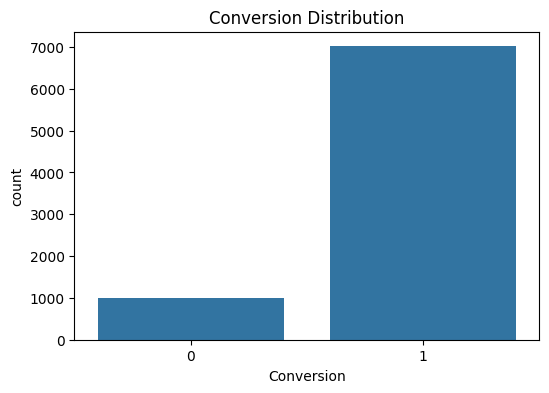

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Conversion', data=df)
plt.title('Conversion Distribution')
plt.show()

## 4. Feature Engineering

In [15]:
# Bu bölümde CustomerID sütununu çıkarıp kategorik sütunları sayısal hale getireceğim.

In [16]:
df = df.drop('CustomerID', axis=1)
df = pd.get_dummies(df, drop_first=True)
df.head()

,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,...,LoyaltyPoints,Conversion,Gender_Male,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention
0,56,136912,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,...,688,1,False,False,False,False,True,False,False,False
1,69,41760,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,...,3459,1,True,False,False,False,False,False,False,True
2,46,88456,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,...,2337,1,False,True,False,False,False,False,False,False
3,32,44085,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,...,2463,1,False,True,False,False,False,False,True,False
4,60,83964,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,...,4345,1,False,True,False,False,False,False,True,False


## 5. Train-Test Split

In [17]:
# Bu bölümde dönüşüm sütununu hedef değişken olarak ayırıp veriyi eğitim ve test olarak böleceğim.

In [18]:
x = df.drop('Conversion', axis=1)
y = df['Conversion']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

x_train.shape, x_test.shape

((6400, 21), (1600, 21))

## 6. Classification Modelleri Kurma

In [19]:
# Bu bölümde birkaç farklı classification modeli kurup sonuçları karşılaştıracağım.

In [20]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, accuracy, f1])
    trained_models[name] = model

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1'])
results_df.sort_values(by='F1', ascending=False)

,Model,Accuracy,F1
3,Gradient Boosting,0.910000,0.950752
0,Logistic Regression,0.891250,0.941176
2,Random Forest,0.886875,0.939119
4,Extra Trees,0.878125,0.934978
1,KNN,0.875625,0.933109


## 7. En İyi Modeli Değerlendirme

In [21]:
# Bu bölümde en başarılı modeli seçip detaylı sonuçlarını inceleyeceğim.

In [22]:
best_model_name = results_df.sort_values(by='F1', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]
best_pred = best_model.predict(x_test)

print('Best Model:', best_model_name)
print('Accuracy:', accuracy_score(y_test, best_pred))
print('F1 Score:', f1_score(y_test, best_pred))
print(classification_report(y_test, best_pred))

Best Model: Gradient Boosting
Accuracy: 0.91
F1 Score: 0.9507523939808481
              precision    recall  f1-score   support

           0       0.85      0.33      0.48       198
           1       0.91      0.99      0.95      1402

    accuracy                           0.91      1600
   macro avg       0.88      0.66      0.71      1600
weighted avg       0.90      0.91      0.89      1600



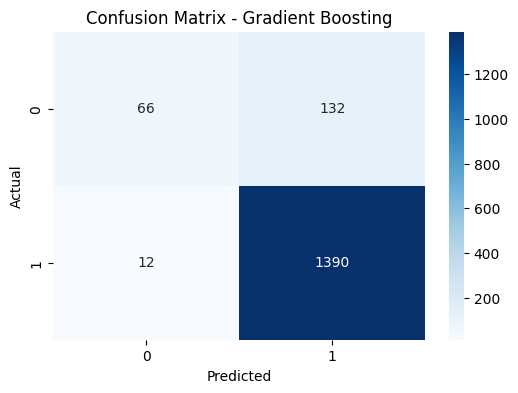

In [23]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8. Örnek Tahmin

In [24]:
# Bu bölümde örnek bir müşteri verisi için dönüşüm tahmini yapacağım.

In [25]:
sample_customer = x_test.iloc[[0]]
sample_prediction = best_model.predict(sample_customer)[0]

print('Tahmin edilen dönüşüm durumu:', sample_prediction)
print('Gerçek değer:', y_test.iloc[0])

Tahmin edilen dönüşüm durumu: 1
Gerçek değer: 1


## 9. Sonuç

In [26]:
# Bu bölümde en iyi modeli yorumlayıp genel sonucu özetleyeceğim.

In [27]:
best_accuracy = results_df.sort_values(by='F1', ascending=False).iloc[0]['Accuracy']
best_f1 = results_df.sort_values(by='F1', ascending=False).iloc[0]['F1']

Bu projede en başarılı model: Gradient Boosting
Accuracy: 0.9100
F1 Score: 0.9508
Bu sonuca göre dijital pazarlama dönüşüm tahmininde en iyi performansı bu model verdi.


Bu projede dijital pazarlama kampanyalarında dönüşüm olup olmayacağını tahmin etmek için farklı classification modelleri denendi. Elde edilen sonuçlara göre en başarılı model 0.9100 accuracy ve 0.9508 F1 score değeri ile Gradient Boosting oldu.